<a href="https://colab.research.google.com/github/yawarabbasmalik/Product-Defects-Detection-Using-Deep-Learning-Text-Analysis/blob/main/Product_Defects_Detection_Using_Deep_Learning_Text_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gzip
import json

# Path to your file
file_path = 'Electronics.jsonl.gz'

# Attributes to be removed
attributes_to_remove = {'images', 'medium_image_url', 'large_image_url', 'asin', 'parent_asin', 'user_id', 'timestamp'}

# Initialize counters and storage for positive and critical records
positive_count, critical_count = 0, 0
max_records_per_label = 25000
positive_data, critical_data = [], []

# Open the gzipped file and process each line
with gzip.open(file_path, 'rt', encoding='utf-8') as file:
    for line in file:
        # Load the line as a JSON object
        data = json.loads(line)

        # Remove the specified attributes
        for attr in attributes_to_remove:
            data.pop(attr, None)

        # Check and label the record
        rating = data.get('rating')
        if rating in [5.0, 4.0] and positive_count < max_records_per_label:
            data['label'] = 'Positive'
            positive_data.append(data)
            positive_count += 1
        elif rating not in [5.0, 4.0, None] and critical_count < max_records_per_label:
            data['label'] = 'Critical'
            critical_data.append(data)
            critical_count += 1

        # Stop processing if enough records of both types are collected
        if positive_count >= max_records_per_label and critical_count >= max_records_per_label:
            break

# Combine the positive and critical records
final_data = positive_data + critical_data


In [ ]:
# Convert the final data to a DataFrame

import pandas as pd

# Convert the final data to a DataFrame
final_df = pd.DataFrame(final_data)

# Display the first few rows of the DataFrame
final_df.head()


,rating,title,text,helpful_vote,verified_purchase,label
0,5.0,Excellent!,I love these. They even come with a carry case...,0,True,Positive
1,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,18,True,Positive
2,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,0,True,Positive
3,5.0,Great Fan! I’m a FAN!,"Light weight, quiet and totally awesome!!! It ...",0,True,Positive
4,5.0,solid sound for the price,Update 2-they sent a new warranty replacement....,0,True,Positive


In [ ]:
# Check for duplicate rows in the DataFrame
duplicates = final_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Check for null values in each column
null_values = final_df.isnull().sum()
print("Number of null values in each column:")
print(null_values)


Number of duplicate rows: 804
Number of null values in each column:
rating               0
title                0
text                 0
helpful_vote         0
verified_purchase    0
label                0
dtype: int64


In [ ]:
# Remove duplicates
final_df = final_df.drop_duplicates()

# Check the number of duplicates after removing duplicates
number_of_duplicates_after_removal = final_df.duplicated().sum()

# Display the number of duplicates
number_of_duplicates_after_removal


0

In [ ]:
# Get the shape of the DataFrame
data_shape = final_df.shape

# Display the shape
data_shape


(49196, 6)

In [ ]:
# Count the number of each label
label_counts = final_df['label'].value_counts()

# Display the counts
label_counts


Critical    24907
Positive    24289
Name: label, dtype: int64

In [ ]:
import pandas as pd
import re

# Function to preprocess text
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation and symbols - keep only alphabetic characters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# Apply the preprocessing function to the 'text' column
final_df['text'] = final_df['text'].astype(str).apply(preprocess_text)

# Display the first few rows to check the preprocessing
final_df.head()


,rating,title,text,helpful_vote,verified_purchase,label
0,5.0,Excellent!,i love these they even come with a carry case ...,0,True,Positive
1,5.0,Great laptop backpack!,i was searching for a sturdy backpack for scho...,18,True,Positive
2,5.0,Best Headphones in the Fifties price range!,ive bought these headphones three times becaus...,0,True,Positive
3,5.0,Great Fan! I’m a FAN!,light weight quiet and totally awesome it does...,0,True,Positive
4,5.0,solid sound for the price,update they sent a new warranty replacement go...,0,True,Positive


In [ ]:
# Define the file path and name for the CSV file
csv_file_path = 'final_data.csv'

# Save the DataFrame as a CSV file
final_df.to_csv(csv_file_path, index=False)

# Inform that the file has been saved
print(f"Data saved to {csv_file_path}")


Data saved to final_data.csv


In [ ]:
# Assuming that the file 'LIWC-22 Results.csv' is in the current working directory of the Jupyter notebook
# and that you have already uploaded it to this environment.

import pandas as pd

# Reading the CSV file
liwc_results_df = pd.read_csv('LIWC-22 Results.csv')

# Displaying the first few rows of the DataFrame
liwc_results_df.head()


,rating,title,text,helpful_vote,verified_purchase,label,Segment,WC,Analytic,Clout,...,nonflu,filler,AllPunc,Period,Comma,QMark,Exclam,Apostro,OtherP,Emoji
0,5.0,Excellent!,i love these they even come with a carry case ...,0,True,Positive,1,94,55.01,23.21,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5.0,Great laptop backpack!,i was searching for a sturdy backpack for scho...,18,True,Positive,1,203,59.76,37.23,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5.0,Best Headphones in the Fifties price range!,ive bought these headphones three times becaus...,0,True,Positive,1,44,12.37,2.53,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5.0,Great Fan! I’m a FAN!,light weight quiet and totally awesome it does...,0,True,Positive,1,45,17.49,27.89,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,solid sound for the price,update they sent a new warranty replacement go...,0,True,Positive,1,40,47.15,81.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Select only the numerical columns from the DataFrame
numerical_columns = liwc_results_df.select_dtypes(include=['number'])

# Extract the label column
label_column = liwc_results_df['label']

# Concatenate the numerical columns with the label column at the end
final_df = pd.concat([numerical_columns, label_column], axis=1)

# Display the first few rows of the final DataFrame
final_df.head()


,rating,helpful_vote,Segment,WC,Analytic,Clout,Authentic,Tone,WPS,BigWords,...,filler,AllPunc,Period,Comma,QMark,Exclam,Apostro,OtherP,Emoji,label
0,5.0,0,1,94,55.01,23.21,57.41,83.95,94.0,7.45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Positive
1,5.0,18,1,203,59.76,37.23,89.80,20.23,203.0,16.26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Positive
2,5.0,0,1,44,12.37,2.53,79.84,98.14,44.0,18.18,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Positive
3,5.0,0,1,45,17.49,27.89,19.26,85.84,45.0,15.56,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Positive
4,5.0,0,1,40,47.15,81.00,95.54,99.00,40.0,20.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Positive


In [ ]:
# Drop the 'rating' column
final_df_without_rating = final_df.drop(columns=['rating'])

# Display the first few rows of the DataFrame without the 'rating' column
final_df_without_rating.head()


,helpful_vote,Segment,WC,Analytic,Clout,Authentic,Tone,WPS,BigWords,Dic,...,filler,AllPunc,Period,Comma,QMark,Exclam,Apostro,OtherP,Emoji,label
0,0,1,94,55.01,23.21,57.41,83.95,94.0,7.45,88.30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Positive
1,18,1,203,59.76,37.23,89.80,20.23,203.0,16.26,86.21,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Positive
2,0,1,44,12.37,2.53,79.84,98.14,44.0,18.18,84.09,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Positive
3,0,1,45,17.49,27.89,19.26,85.84,45.0,15.56,84.44,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Positive
4,0,1,40,47.15,81.00,95.54,99.00,40.0,20.00,80.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Positive


In [ ]:
import pandas as pd

# Load the CSV file
file_path = 'InfoGain Feature.csv'
df = pd.read_csv(file_path)

df.head()

,Clout,Authentic,Tone,auxverb,negate,Cognition,cogproc,differ,Affect,tone_pos,tone_neg,emotion,emo_pos,emo_neg,focuspast,label
0,23.21,57.41,83.95,5.32,0,9.57,8.51,2.13,6.38,5.32,1.06,2.13,1.06,1.06,1.06,Positive
1,37.23,89.8,20.23,4.43,0.49,11.33,10.84,3.45,5.42,2.46,2.46,2.96,1.48,0.99,1.48,Positive
2,2.53,79.84,98.14,6.82,2.27,9.09,9.09,2.27,6.82,6.82,0,4.55,4.55,0,4.55,Positive
3,27.89,19.26,85.84,4.44,2.22,13.33,13.33,4.44,4.44,4.44,0,2.22,2.22,0,0,Positive
4,81,95.54,99,7.5,0,5,5,5,12.5,10,2.5,5,5,0,7.5,Positive


In [ ]:
# Code to replace '?' with NA (NaN) in the dataframe
df.replace('?', pd.NA, inplace=True)

# Displaying the first few rows of the dataframe to verify the changes
df.head()


,Clout,Authentic,Tone,auxverb,negate,Cognition,cogproc,differ,Affect,tone_pos,tone_neg,emotion,emo_pos,emo_neg,focuspast,label
0,23.21,57.41,83.95,5.32,0,9.57,8.51,2.13,6.38,5.32,1.06,2.13,1.06,1.06,1.06,Positive
1,37.23,89.8,20.23,4.43,0.49,11.33,10.84,3.45,5.42,2.46,2.46,2.96,1.48,0.99,1.48,Positive
2,2.53,79.84,98.14,6.82,2.27,9.09,9.09,2.27,6.82,6.82,0,4.55,4.55,0,4.55,Positive
3,27.89,19.26,85.84,4.44,2.22,13.33,13.33,4.44,4.44,4.44,0,2.22,2.22,0,0,Positive
4,81,95.54,99,7.5,0,5,5,5,12.5,10,2.5,5,5,0,7.5,Positive


In [ ]:
# Check for null values
null_values = df.isnull().sum()
null_values

Clout        5548
Authentic    3806
Tone         8515
auxverb        35
negate         35
Cognition      35
cogproc        35
differ         35
Affect         35
tone_pos       35
tone_neg       35
emotion        35
emo_pos        35
emo_neg        35
focuspast      35
label           0
dtype: int64

In [ ]:
# Removing rows with NA values from the dataframe
df = df.dropna()

# Displaying the first few rows of the cleaned dataframe to verify the changes
df.head()


,Clout,Authentic,Tone,auxverb,negate,Cognition,cogproc,differ,Affect,tone_pos,tone_neg,emotion,emo_pos,emo_neg,focuspast,label
0,23.21,57.41,83.95,5.32,0,9.57,8.51,2.13,6.38,5.32,1.06,2.13,1.06,1.06,1.06,Positive
1,37.23,89.8,20.23,4.43,0.49,11.33,10.84,3.45,5.42,2.46,2.46,2.96,1.48,0.99,1.48,Positive
2,2.53,79.84,98.14,6.82,2.27,9.09,9.09,2.27,6.82,6.82,0,4.55,4.55,0,4.55,Positive
3,27.89,19.26,85.84,4.44,2.22,13.33,13.33,4.44,4.44,4.44,0,2.22,2.22,0,0,Positive
4,81,95.54,99,7.5,0,5,5,5,12.5,10,2.5,5,5,0,7.5,Positive


In [ ]:
# Correcting the approach to handle non-numeric characters in the data
def safe_convert_to_float(column):
    # Convert non-numeric values to NaN and then to float
    return pd.to_numeric(column, errors='coerce')

# Apply this function to the necessary columns
df['emo_pos'] = safe_convert_to_float(df['emo_pos'])
df['emo_neg'] = safe_convert_to_float(df['emo_neg'])
df['Authentic'] = safe_convert_to_float(df['Authentic'])
df['Cognition'] = safe_convert_to_float(df['Cognition'])
df['focuspast'] = safe_convert_to_float(df['focuspast'])
df['Tone'] = safe_convert_to_float(df['Tone'])
df['tone_neg'] = safe_convert_to_float(df['tone_neg'])
df['tone_pos'] = safe_convert_to_float(df['tone_pos'])
df['cogproc'] = safe_convert_to_float(df['cogproc'])
df['negate'] = safe_convert_to_float(df['negate'])
df['auxverb'] = safe_convert_to_float(df['auxverb'])

# Recalculating the derived attributes with corrected approach
df['EmotionalIntensity'] = (df['emo_pos'] + df['emo_neg']) / 2
df['ReviewClarity'] = (df['Authentic'] + df['Cognition']) / 2
df['PastFocusIntensity'] = df['focuspast'] * df['Tone']
df['NegativeSentimentRatio'] = df['tone_neg'] / (df['tone_pos'] + df['tone_neg'])
df['CognitiveComplexity'] = df['cogproc'] / (df['negate'] + df['auxverb'])




In [ ]:
df.head()

,Clout,Authentic,Tone,auxverb,negate,Cognition,cogproc,differ,Affect,tone_pos,...,emotion,emo_pos,emo_neg,focuspast,label,EmotionalIntensity,ReviewClarity,PastFocusIntensity,NegativeSentimentRatio,CognitiveComplexity
0,23.21,57.41,83.95,5.32,0.00,9.57,8.51,2.13,6.38,5.32,...,2.13,1.06,1.06,1.06,Positive,1.060,33.490,88.9870,0.166144,1.599624
1,37.23,89.80,20.23,4.43,0.49,11.33,10.84,3.45,5.42,2.46,...,2.96,1.48,0.99,1.48,Positive,1.235,50.565,29.9404,0.500000,2.203252
2,2.53,79.84,98.14,6.82,2.27,9.09,9.09,2.27,6.82,6.82,...,4.55,4.55,0.00,4.55,Positive,2.275,44.465,446.5370,0.000000,1.000000
3,27.89,19.26,85.84,4.44,2.22,13.33,13.33,4.44,4.44,4.44,...,2.22,2.22,0.00,0.00,Positive,1.110,16.295,0.0000,0.000000,2.001502
4,81,95.54,99.00,7.50,0.00,5.00,5.00,5,12.5,10.00,...,5,5.00,0.00,7.50,Positive,2.500,50.270,742.5000,0.200000,0.666667


In [ ]:
# Displaying the descriptive statistics of the dataset
df.describe()


,Authentic,Tone,auxverb,negate,Cognition,cogproc,tone_pos,tone_neg,emo_pos,emo_neg,focuspast,EmotionalIntensity,ReviewClarity,PastFocusIntensity,NegativeSentimentRatio,CognitiveComplexity
count,36594.000000,36594.000000,36594.000000,36594.000000,36594.000000,36594.000000,36594.000000,36594.000000,36594.000000,36594.000000,36594.000000,36594.000000,36594.000000,36594.000000,36594.000000,3.605800e+04
mean,55.650283,60.877241,8.422269,2.511798,13.256065,11.941550,4.972973,1.286899,1.481024,0.469869,4.361938,0.975447,34.453174,254.539648,0.223166,inf
std,32.416020,33.782126,4.210321,3.089924,6.363518,5.931736,4.771350,2.685441,2.843854,1.392065,4.289255,1.538982,16.910037,345.998568,0.309446,NaN
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000e+00
25%,26.780000,32.515000,6.120000,0.000000,9.560000,8.330000,2.110000,0.000000,0.000000,0.000000,1.110000,0.000000,19.795000,8.419600,0.000000,7.998560e-01
50%,58.850000,66.580000,8.400000,1.890000,12.900000,11.630000,3.700000,0.000000,0.225000,0.000000,3.450000,0.520000,35.965000,139.289800,0.000000,1.070810e+00
75%,86.260000,95.420000,10.650000,3.490000,16.380000,14.930000,6.380000,1.690000,1.880000,0.150000,6.350000,1.300000,49.605000,352.180500,0.363912,1.500000e+00
max,99.000000,99.000000,50.000000,50.000000,100.000000,75.000000,100.000000,100.000000,60.000000,50.000000,50.000000,30.000000,99.500000,4950.000000,1.000000,inf


In [ ]:
# Moving the 'Label' column to the end of the dataframe
label_column = df.pop('label')
df = pd.concat([df, label_column], axis=1)

# Displaying the first few rows of the reordered dataframe to verify the changes
df.head()


,Clout,Authentic,Tone,auxverb,negate,Cognition,cogproc,differ,Affect,tone_pos,...,emotion,emo_pos,emo_neg,focuspast,EmotionalIntensity,ReviewClarity,PastFocusIntensity,NegativeSentimentRatio,CognitiveComplexity,label
0,23.21,57.41,83.95,5.32,0.00,9.57,8.51,2.13,6.38,5.32,...,2.13,1.06,1.06,1.06,1.060,33.490,88.9870,0.166144,1.599624,Positive
1,37.23,89.80,20.23,4.43,0.49,11.33,10.84,3.45,5.42,2.46,...,2.96,1.48,0.99,1.48,1.235,50.565,29.9404,0.500000,2.203252,Positive
2,2.53,79.84,98.14,6.82,2.27,9.09,9.09,2.27,6.82,6.82,...,4.55,4.55,0.00,4.55,2.275,44.465,446.5370,0.000000,1.000000,Positive
3,27.89,19.26,85.84,4.44,2.22,13.33,13.33,4.44,4.44,4.44,...,2.22,2.22,0.00,0.00,1.110,16.295,0.0000,0.000000,2.001502,Positive
4,81,95.54,99.00,7.50,0.00,5.00,5.00,5,12.5,10.00,...,5,5.00,0.00,7.50,2.500,50.270,742.5000,0.200000,0.666667,Positive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Assuming 'df' is the dataframe to be cleaned and normalized
# Step 1 & 2: Identify and Replace Infinite Values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Step 3: Handling NaN values (Optionally, you can fill NaN values instead of dropping)
df.dropna(inplace=True)

# Separating the features and the label
features = df.drop('label', axis=1)
labels = df['label']

# Step 4: Normalize the Data
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(features)

# Creating a new DataFrame for the normalized features
normalized_df = pd.DataFrame(normalized_features, columns=features.columns)
normalized_df = pd.concat([normalized_df, labels.reset_index(drop=True)], axis=1)


In [ ]:
df = normalized_df
df.head()

,Clout,Authentic,Tone,auxverb,negate,Cognition,cogproc,differ,Affect,tone_pos,...,emotion,emo_pos,emo_neg,focuspast,EmotionalIntensity,ReviewClarity,PastFocusIntensity,NegativeSentimentRatio,CognitiveComplexity,label
0,0.226633,0.575612,0.846429,0.1064,0.0000,0.0957,0.113467,0.035500,0.061077,0.0532,...,0.0426,0.0212,0.0212,0.0212,0.0424,0.333232,0.017977,0.166144,0.132969,Positive
1,0.369694,0.906122,0.196224,0.0886,0.0098,0.1133,0.144533,0.057500,0.051449,0.0246,...,0.0592,0.0296,0.0198,0.0296,0.0494,0.505707,0.006049,0.500000,0.183145,Positive
2,0.015612,0.804490,0.991224,0.1364,0.0454,0.0909,0.121200,0.037833,0.065490,0.0682,...,0.0910,0.0910,0.0000,0.0910,0.0910,0.444091,0.090209,0.000000,0.083125,Positive
3,0.274388,0.186327,0.865714,0.0888,0.0444,0.1333,0.177733,0.074000,0.041621,0.0444,...,0.0444,0.0444,0.0000,0.0000,0.0444,0.159545,0.000000,0.000000,0.166375,Positive
4,0.816327,0.964694,1.000000,0.1500,0.0000,0.0500,0.066667,0.083333,0.122455,0.1000,...,0.1000,0.1000,0.0000,0.1500,0.1000,0.502727,0.150000,0.200000,0.055417,Positive


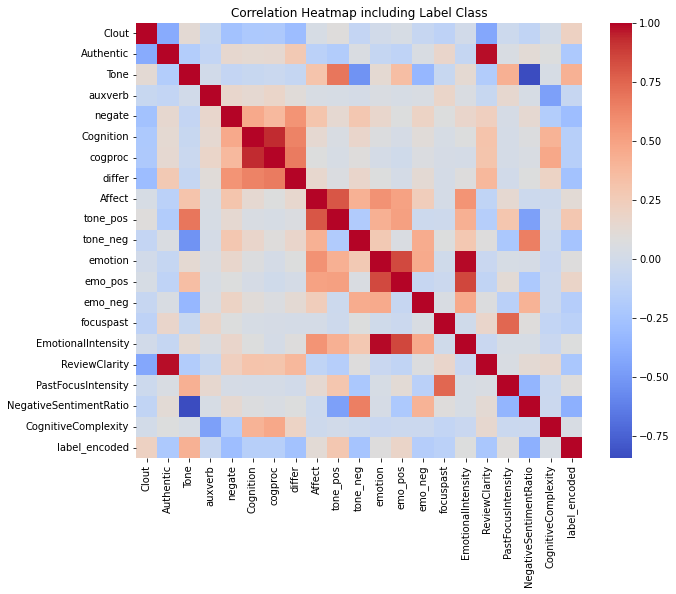

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Encode the 'label' column for correlation analysis
# label_encoder = LabelEncoder()
data_encoded = df.copy()
data_encoded['label_encoded'] = label_encoder.fit_transform(df['label'])

# Compute the correlation matrix
corr = data_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap including Label Class')
plt.show()


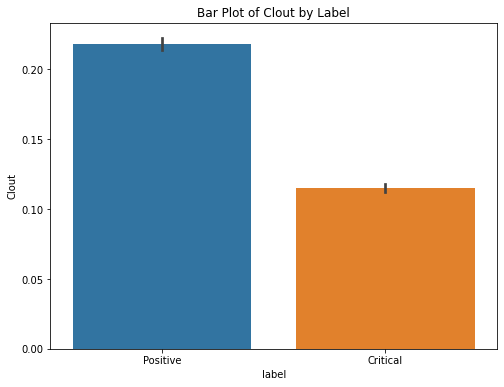

In [ ]:
# Selecting three variables for bar plots
# These selections are based on variety and potential interest
selected_columns = ['Clout']

# Creating a bar plot for a single attribute 'Clout'
plt.figure(figsize=(8, 6))
sns.barplot(x='label', y='Clout', data=df)
plt.title('Bar Plot of Clout by Label')
plt.show()



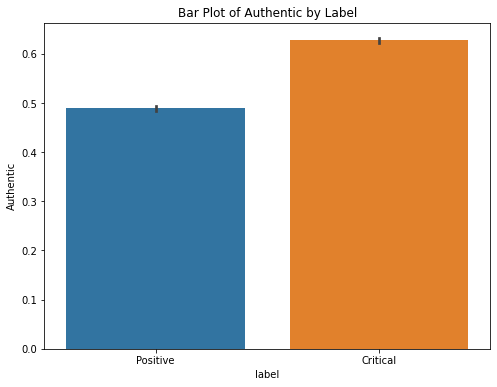

In [ ]:
# Selecting three variables for bar plots
# These selections are based on variety and potential interest
selected_columns = ['Authentic']

# Creating a bar plot for a single attribute 'Authentic'
plt.figure(figsize=(8, 6))
sns.barplot(x='label', y='Authentic', data=df)
plt.title('Bar Plot of Authentic by Label')
plt.show()


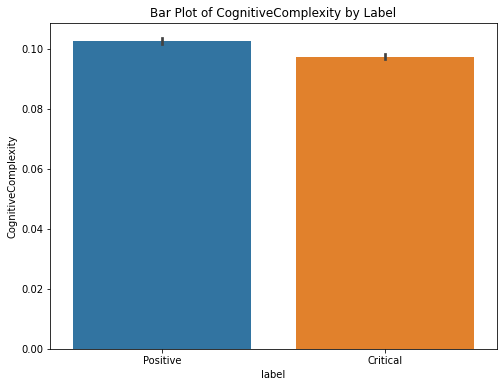

In [ ]:
# Selecting three variables for bar plots
# These selections are based on variety and potential interest
selected_columns = ['CognitiveComplexity']

# Creating a bar plot for a single attribute 'CognitiveComplexity'
plt.figure(figsize=(8, 6))
sns.barplot(x='label', y='CognitiveComplexity', data=df)
plt.title('Bar Plot of CognitiveComplexity by Label')
plt.show()

In [ ]:
# Checking the shape of the dataframe and counts of labels
data_shape = df.shape
label_counts = df['label'].value_counts()

data_shape, label_counts


((34630, 21),
 Critical    17680
 Positive    16950
 Name: label, dtype: int64)

In [ ]:
# Getting the names of all columns in the dataframe
column_names = df.columns.tolist()
column_names


['Clout',
 'Authentic',
 'Tone',
 'auxverb',
 'negate',
 'Cognition',
 'cogproc',
 'differ',
 'Affect',
 'tone_pos',
 'tone_neg',
 'emotion',
 'emo_pos',
 'emo_neg',
 'focuspast',
 'EmotionalIntensity',
 'ReviewClarity',
 'PastFocusIntensity',
 'NegativeSentimentRatio',
 'CognitiveComplexity',
 'label']

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Assuming 'normalized_df' is your normalized dataframe
X = df.drop('label', axis=1)
y = df['label']

# Encode the labels if they are not numerical
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Define Logistic Regression model
model = LogisticRegression()

# Define evaluation metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1_score': make_scorer(f1_score, average='weighted'),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True, average='weighted')
}

# 10-Fold Cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
cv_results = cross_validate(model, X, y_encoded, cv=kfold, scoring=scoring, n_jobs=-1, return_train_score=False)

# Print the results
print("Logistic Regression Evaluation:")
for metric in scoring.keys():
    average_score = np.mean(cv_results[f'test_{metric}'])
    print(f"{metric}: {average_score:.4f}")



Logistic Regression Evaluation:
accuracy: 0.7433
precision: 0.7434
recall: 0.7433
f1_score: 0.7433
roc_auc: 0.8213


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Define the Naive Bayes model
model = GaussianNB()

# Define the evaluation metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1_score': make_scorer(f1_score, average='weighted'),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True, average='weighted')
}

# Perform 10-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
cv_results = cross_validate(model, X, y_encoded, cv=kfold, scoring=scoring, n_jobs=-1, return_train_score=False)

# Print the results
print("Naive Bayes Evaluation:")
for metric in scoring.keys():
    average_score = np.mean(cv_results[f'test_{metric}'])
    print(f"{metric}: {average_score:.4f}")

Naive Bayes Evaluation:
accuracy: 0.7153
precision: 0.7301
recall: 0.7153
f1_score: 0.7119
roc_auc: 0.8010


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Define the AdaBoost model
model = AdaBoostClassifier()

# Define the evaluation metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1_score': make_scorer(f1_score, average='weighted'),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True, average='weighted')
}

# Perform 10-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
cv_results = cross_validate(model, X, y_encoded, cv=kfold, scoring=scoring, n_jobs=-1, return_train_score=False)

# Print the results
print("AdaBoost Evaluation:")
for metric in scoring.keys():
    average_score = np.mean(cv_results[f'test_{metric}'])
    print(f"{metric}: {average_score:.4f}")


AdaBoost Evaluation:
accuracy: 0.7432
precision: 0.7433
recall: 0.7432
f1_score: 0.7432
roc_auc: 0.8209


In [ ]:
from xgboost import XGBClassifier

# Define the XGBoost model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Define the evaluation metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1_score': make_scorer(f1_score, average='weighted'),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True, average='weighted')
}

# Perform 10-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
cv_results = cross_validate(model, X, y_encoded, cv=kfold, scoring=scoring, n_jobs=-1, return_train_score=False)

# Print the results
print("XGBoost Evaluation:")
for metric in scoring.keys():
    average_score = np.mean(cv_results[f'test_{metric}'])
    print(f"{metric}: {average_score:.4f}")


XGBoost Evaluation:
accuracy: 0.7451
precision: 0.7451
recall: 0.7451
f1_score: 0.7450
roc_auc: 0.8217


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Define the Decision Tree model
model = DecisionTreeClassifier()

# Define the evaluation metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1_score': make_scorer(f1_score, average='weighted'),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True, average='weighted')
}

# Perform 10-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
cv_results = cross_validate(model, X, y_encoded, cv=kfold, scoring=scoring, n_jobs=-1, return_train_score=False)

# Print the results
print("Decision Tree Evaluation:")
for metric in scoring.keys():
    average_score = np.mean(cv_results[f'test_{metric}'])
    print(f"{metric}: {average_score:.4f}")


Decision Tree Evaluation:
accuracy: 0.6642
precision: 0.6642
recall: 0.6642
f1_score: 0.6642
roc_auc: 0.6640


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define the Random Forest model
model = RandomForestClassifier()

# Define the evaluation metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1_score': make_scorer(f1_score, average='weighted'),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True, average='weighted')
}

# Perform 10-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
cv_results = cross_validate(model, X, y_encoded, cv=kfold, scoring=scoring, n_jobs=-1, return_train_score=False)

# Print the results
print("Random Forest Evaluation:")
for metric in scoring.keys():
    average_score = np.mean(cv_results[f'test_{metric}'])
    print(f"{metric}: {average_score:.4f}")


Random Forest Evaluation:
accuracy: 0.7472
precision: 0.7477
recall: 0.7472
f1_score: 0.7468
roc_auc: 0.8223


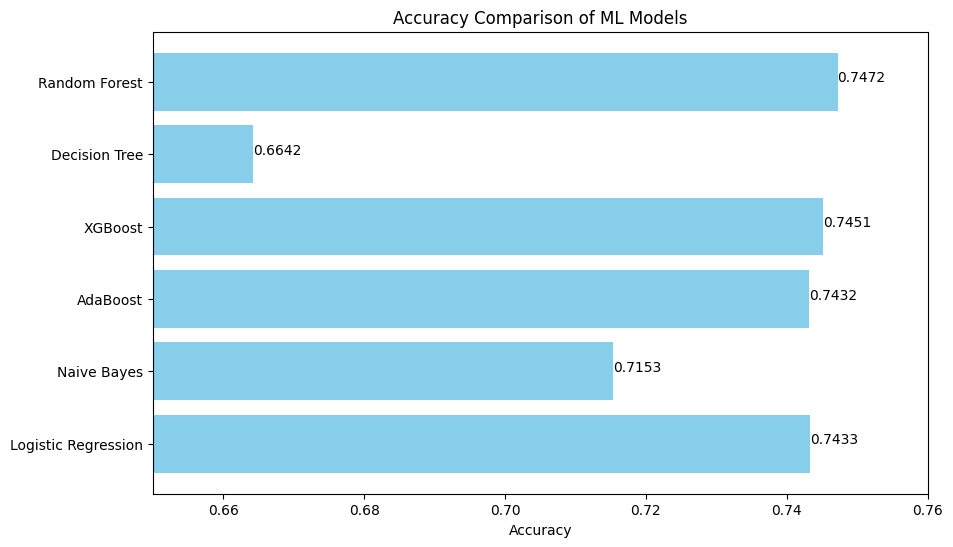

In [ ]:
import matplotlib.pyplot as plt

# Model names
models = ['Logistic Regression', 'Naive Bayes', 'AdaBoost', 'XGBoost', 'Decision Tree', 'Random Forest']

# Accuracy scores
accuracies = [0.7433, 0.7153, 0.7432, 0.7451, 0.6642, 0.7472]

# Creating bar plot
plt.figure(figsize=(10, 6))
plt.barh(models, accuracies, color='skyblue')
plt.xlabel('Accuracy')
plt.title('Accuracy Comparison of ML Models')
plt.xlim(0.65, 0.76)  # Setting the limit for x-axis for better visual comparison

# Display the accuracy values on the bars
for index, value in enumerate(accuracies):
    plt.text(value, index, str(value))

# Show plot
plt.show()


## Categorical Variables

### 1. Linguistic Attributes

In [ ]:
# Using the specified features and the target class for the Random Forest model
feature_columns = ['Clout', 'Authentic', 'auxverb', 'negate', 'focuspast']
target_column = 'label'

# Check if these columns are present in the dataset
if all(column in df.columns for column in feature_columns + [target_column]):
    # Extracting the specified features and label
    X = df[feature_columns]
    y = df[target_column]

    # Encode the labels if they are not numeric
    if y.dtype == 'object':
        label_encoder = LabelEncoder()
        y_encoded = label_encoder.fit_transform(y)
    else:
        y_encoded = y

    # Redefining the Random Forest model and evaluation metrics
    model = RandomForestClassifier()
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, average='weighted'),
        'recall': make_scorer(recall_score, average='weighted'),
        'f1_score': make_scorer(f1_score, average='weighted'),
        'roc_auc': make_scorer(roc_auc_score, needs_proba=True, average='weighted')
    }
    kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
    cv_results = cross_validate(model, X, y_encoded, cv=kfold, scoring=scoring, n_jobs=-1, return_train_score=False)

    # Preparing the results
    modified_random_forest_results = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring.keys()}
else:
    modified_random_forest_results = "Required columns for the model are missing in the dataset."

modified_random_forest_results



{'accuracy': 0.6548657233612474,
 'precision': 0.6548908600784028,
 'recall': 0.6548657233612474,
 'f1_score': 0.6546871174359077,
 'roc_auc': 0.7054159825945355}

### 2. Emotional Tone

In [ ]:
# Using the specified features and the target class for the Random Forest model
feature_columns = ['Tone', 'Affect', 'tone_pos', 'tone_neg', 'emotion', 'emo_pos', 'emo_neg']
target_column = 'label'

# Check if these columns are present in the dataset
if all(column in df.columns for column in feature_columns + [target_column]):
    # Extracting the specified features and label
    X = df[feature_columns]
    y = df[target_column]

    # Encode the labels if they are not numeric
    if y.dtype == 'object':
        label_encoder = LabelEncoder()
        y_encoded = label_encoder.fit_transform(y)
    else:
        y_encoded = y

    # Redefining the Random Forest model and evaluation metrics
    model = RandomForestClassifier()
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, average='weighted'),
        'recall': make_scorer(recall_score, average='weighted'),
        'f1_score': make_scorer(f1_score, average='weighted'),
        'roc_auc': make_scorer(roc_auc_score, needs_proba=True, average='weighted')
    }
    kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
    cv_results = cross_validate(model, X, y_encoded, cv=kfold, scoring=scoring, n_jobs=-1, return_train_score=False)

    # Preparing the results
    modified_random_forest_results = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring.keys()}
else:
    modified_random_forest_results = "Required columns for the model are missing in the dataset."

modified_random_forest_results



{'accuracy': 0.6606699393589375,
 'precision': 0.6612017955208224,
 'recall': 0.6606699393589375,
 'f1_score': 0.6606649648107098,
 'roc_auc': 0.7198535918792297}

### 3. Congnitive Processes

In [ ]:
# Using the specified features and the target class for the Random Forest model
feature_columns = ['Cognition', 'cogproc', 'differ']
target_column = 'label'

# Check if these columns are present in the dataset
if all(column in df.columns for column in feature_columns + [target_column]):
    # Extracting the specified features and label
    X = df[feature_columns]
    y = df[target_column]

    # Encode the labels if they are not numeric
    if y.dtype == 'object':
        label_encoder = LabelEncoder()
        y_encoded = label_encoder.fit_transform(y)
    else:
        y_encoded = y

    # Redefining the Random Forest model and evaluation metrics
    model = RandomForestClassifier()
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, average='weighted'),
        'recall': make_scorer(recall_score, average='weighted'),
        'f1_score': make_scorer(f1_score, average='weighted'),
        'roc_auc': make_scorer(roc_auc_score, needs_proba=True, average='weighted')
    }
    kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
    cv_results = cross_validate(model, X, y_encoded, cv=kfold, scoring=scoring, n_jobs=-1, return_train_score=False)

    # Preparing the results
    modified_random_forest_results = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring.keys()}
else:
    modified_random_forest_results = "Required columns for the model are missing in the dataset."

modified_random_forest_results



{'accuracy': 0.5800173260179036,
 'precision': 0.5798411696089151,
 'recall': 0.5800173260179036,
 'f1_score': 0.5796608530965874,
 'roc_auc': 0.6072903569188056}

### 4. Derived Attributes

In [ ]:
# Using the specified features and the target class for the Random Forest model
feature_columns = ['EmotionalIntensity', 'ReviewClarity', 'PastFocusIntensity', 'NegativeSentimentRatio', 'CognitiveComplexity']
target_column = 'label'

# Check if these columns are present in the dataset
if all(column in df.columns for column in feature_columns + [target_column]):
    # Extracting the specified features and label
    X = df[feature_columns]
    y = df[target_column]

    # Encode the labels if they are not numeric
    if y.dtype == 'object':
        label_encoder = LabelEncoder()
        y_encoded = label_encoder.fit_transform(y)
    else:
        y_encoded = y

    # Redefining the Random Forest model and evaluation metrics
    model = RandomForestClassifier()
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, average='weighted'),
        'recall': make_scorer(recall_score, average='weighted'),
        'f1_score': make_scorer(f1_score, average='weighted'),
        'roc_auc': make_scorer(roc_auc_score, needs_proba=True, average='weighted')
    }
    kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
    cv_results = cross_validate(model, X, y_encoded, cv=kfold, scoring=scoring, n_jobs=-1, return_train_score=False)

    # Preparing the results
    modified_random_forest_results = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring.keys()}
else:
    modified_random_forest_results = "Required columns for the model are missing in the dataset."

modified_random_forest_results



{'accuracy': 0.6832803927230724,
 'precision': 0.6832993581132201,
 'recall': 0.6832803927230724,
 'f1_score': 0.6832346968563583,
 'roc_auc': 0.7482511445694684}

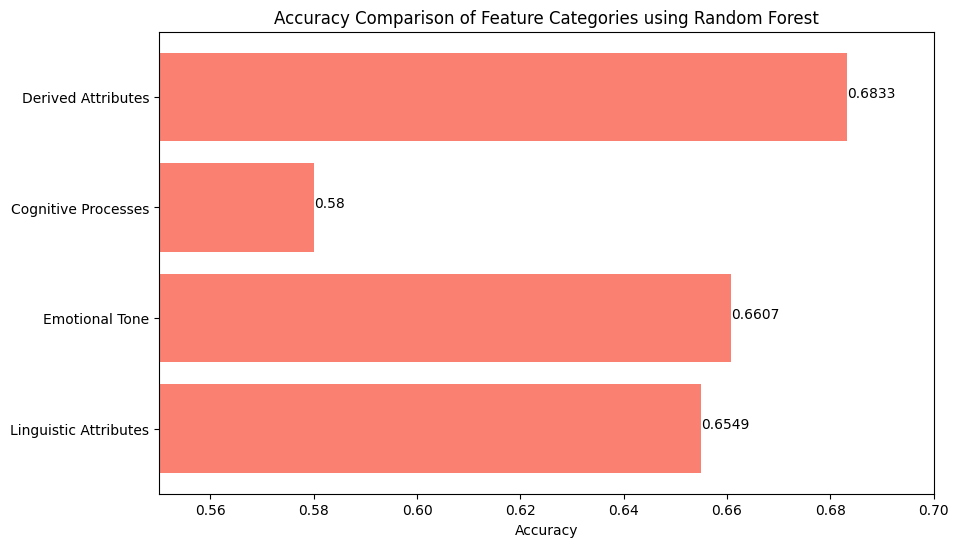

In [ ]:
# Categories
categories = ['Linguistic Attributes', 'Emotional Tone', 'Cognitive Processes', 'Derived Attributes']

# Accuracy scores for each category
category_accuracies = [0.6549, 0.6607, 0.5800, 0.6833]

# Creating bar plot
plt.figure(figsize=(10, 6))
plt.barh(categories, category_accuracies, color='salmon')
plt.xlabel('Accuracy')
plt.title('Accuracy Comparison of Feature Categories using Random Forest')
plt.xlim(0.55, 0.70)  # Setting the limit for x-axis for better visual comparison

# Display the accuracy values on the bars
for index, value in enumerate(category_accuracies):
    plt.text(value, index, str(value))

# Show plot
plt.show()


## Variable Importance

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np


# Assuming the last column is the target variable
X = df.iloc[:, :-1]  # All columns except the last one
y = df.iloc[:, -1]   # Last column

# Encode the labels if they are not numeric
if y.dtype == 'object':
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

# Train the Random Forest model
rf_model = RandomForestClassifier()
rf_model.fit(X, y)

# Retrieve feature importances and sort them in descending order
importances = rf_model.feature_importances_
sorted_indices = np.argsort(importances)[::-1]

# Prepare the sorted importances for display
sorted_importances = [(X.columns[idx], importances[idx]) for idx in sorted_indices]

# Print the sorted importances
for feature, importance in sorted_importances:
    print(f"{feature}: {importance}")


negate: 0.09893570212465007
Tone: 0.08055606866366498
differ: 0.07563057020659716
NegativeSentimentRatio: 0.06504581855953324
tone_pos: 0.06474038038124037
ReviewClarity: 0.05432119207170534
Clout: 0.04913457942770522
tone_neg: 0.047845904593683694
auxverb: 0.047162300693758055
Authentic: 0.04701654596222685
Cognition: 0.04660543166811461
CognitiveComplexity: 0.04620435675493212
cogproc: 0.04572042866204261
focuspast: 0.04535060217680801
Affect: 0.044392189017537324
PastFocusIntensity: 0.0423208037173235
emo_pos: 0.031864320020797594
emotion: 0.026325445409055778
EmotionalIntensity: 0.025051913509762613
emo_neg: 0.015775446378860962


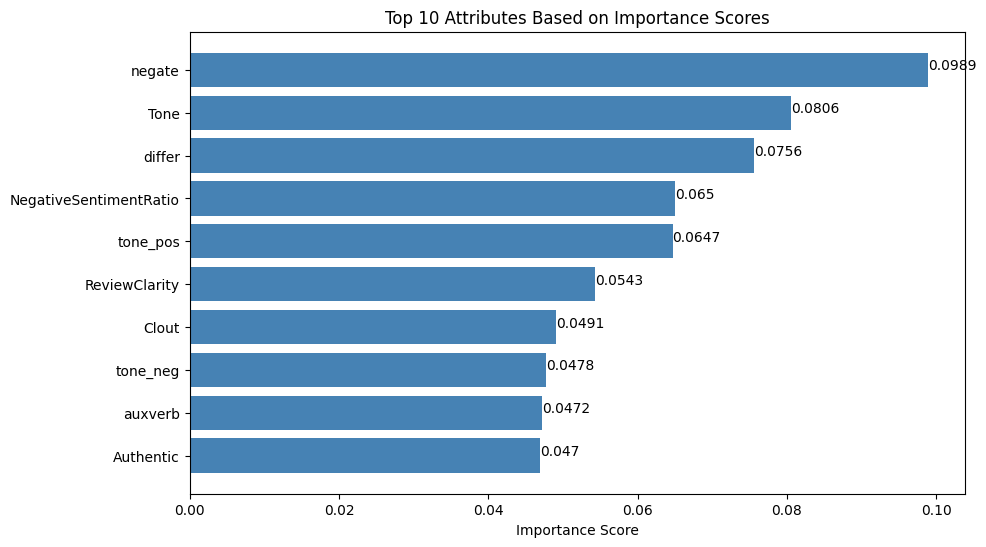

In [ ]:
# Attributes and their importance scores
attributes = ['negate', 'Tone', 'differ', 'NegativeSentimentRatio', 'tone_pos',
              'ReviewClarity', 'Clout', 'tone_neg', 'auxverb', 'Authentic']
importance_scores = [0.0989, 0.0806, 0.0756, 0.0650, 0.0647,
                     0.0543, 0.0491, 0.0478, 0.0472, 0.0470]

# Creating bar plot
plt.figure(figsize=(10, 6))
plt.barh(attributes, importance_scores, color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Attributes Based on Importance Scores')
plt.gca().invert_yaxis()  # To display the highest importance on top

# Display the importance values on the bars
for index, value in enumerate(importance_scores):
    plt.text(value, index, str(round(value, 4)))

# Show plot
plt.show()


In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("/content/final_data.csv")

df.head()

,rating,title,text,helpful_vote,verified_purchase,label
0,5.0,Excellent!,i love these they even come with a carry case ...,0,True,Positive
1,5.0,Great laptop backpack!,i was searching for a sturdy backpack for scho...,18,True,Positive
2,5.0,Best Headphones in the Fifties price range!,ive bought these headphones three times becaus...,0,True,Positive
3,5.0,Great Fan! I’m a FAN!,light weight quiet and totally awesome it does...,0,True,Positive
4,5.0,solid sound for the price,update they sent a new warranty replacement go...,0,True,Positive


In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Function to clean and preprocess the text
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Remove punctuations and special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenization (splitting text into words)
    tokens = text.split()
    # Removing stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Applying the cleaning function to your text data
df['cleaned_text'] = df['text'].apply(clean_text)

# Check if 'label' column is present
if 'label' not in df.columns:
    raise ValueError("Label column is missing from the DataFrame")

# Display the DataFrame to confirm
df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,rating,title,text,helpful_vote,verified_purchase,label,cleaned_text
0,5.0,Excellent!,i love these they even come with a carry case ...,0,True,Positive,love even come carry case several sizes ear bu...
1,5.0,Great laptop backpack!,i was searching for a sturdy backpack for scho...,18,True,Positive,searching sturdy backpack school would allow c...
2,5.0,Best Headphones in the Fifties price range!,ive bought these headphones three times becaus...,0,True,Positive,ive bought headphones three times love much ov...
3,5.0,Great Fan! I’m a FAN!,light weight quiet and totally awesome it does...,0,True,Positive,light weight quiet totally awesome doesnt come...
4,5.0,solid sound for the price,update they sent a new warranty replacement go...,0,True,Positive,update sent new warranty replacement good comp...


In [ ]:
# Assuming 'df' is your current DataFrame

# Creating a new DataFrame with only 'label' and 'cleaned_text' columns
new_df = df[['label', 'cleaned_text']]

# Display the first few rows of the new DataFrame
new_df.head()


,label,cleaned_text
0,Positive,love even come carry case several sizes ear bu...
1,Positive,searching sturdy backpack school would allow c...
2,Positive,ive bought headphones three times love much ov...
3,Positive,light weight quiet totally awesome doesnt come...
4,Positive,update sent new warranty replacement good comp...


## LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Constants
VOCAB_SIZE = 10000  # This is a hyperparameter
MAX_LENGTH = 200    # Max length of each sequence
EMBEDDING_DIM = 100 # Size of the word embeddings
OOV_TOK = "<OOV>"

# Assuming new_df is your DataFrame with 'cleaned_text' and 'label'
texts = new_df['cleaned_text'].astype(str).values
labels = new_df['label'].values

# Encoding labels (if they are not already numerical)
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Tokenizing the text
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOK)
tokenizer.fit_on_texts(X_train)
word_index = tokenizer.word_index

# Convert text to sequences of integers
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

# Padding sequences to ensure uniform length
train_padded = pad_sequences(train_sequences, maxlen=MAX_LENGTH, truncating='post', padding='post')
test_padded = pad_sequences(test_sequences, maxlen=MAX_LENGTH, truncating='post', padding='post')

# LSTM Model
model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LENGTH),
    LSTM(64, return_sequences=False),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Training the model
model.fit(train_padded, y_train, epochs=10, validation_data=(test_padded, y_test))

# Evaluating the model on the test data
y_pred = model.predict(test_padded)
y_pred = (y_pred > 0.5).astype("int32")  # Convert probabilities to binary predictions

# Calculating metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 200, 100)          1000000   
                                                                 
 lstm_2 (LSTM)               (None, 64)                42240     
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1042305 (3.98 MB)
Trainable params: 1042305 (3.98 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
1230/1230 [==============================] - 183s 147ms/step - loss: 0.6935 - accuracy: 0.5043 - val_loss: 0.6927 - val_accuracy: 0.5128
Epoch 2/10
1230/1230 [==============================] - 184s 150ms/step - loss: 0.6888 - accuracy: 0.5105 - val_loss: 0.6947 - val_a

## Word2Vec

In [ ]:
!pip install gensim

In [ ]:
import pandas as pd
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')

# Tokenizing each document
df['tokenized_text'] = df['cleaned_text'].apply(word_tokenize)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
from gensim.models import Word2Vec

# Training the Word2Vec model
word2vec_model = Word2Vec(df['tokenized_text'], vector_size=100, window=5, min_count=2, workers=4)


In [ ]:
import numpy as np

# Function to create a feature vector by averaging all word vectors in a document
def document_vector(doc, model):
    # Remove out-of-vocabulary words
    doc = [word for word in doc if word in model.wv.index_to_key]
    if not doc:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[doc], axis=0)

# Apply the function to each document
df['doc_vector'] = df['tokenized_text'].apply(lambda x: document_vector(x, word2vec_model))


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encoding labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

# Splitting the data
X = np.array(df['doc_vector'].tolist())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(100,)),  # Input shape is 100 for Word2Vec features
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Assuming binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               12928     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 21249 (83.00 KB)
Trainable params: 21249 (83.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
1230/1230

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict on test data
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype("int32")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


308/308 [==============================] - 1s 2ms/step
Accuracy: 0.8072
Precision: 0.8273
Recall: 0.7659
F1-Score: 0.7954


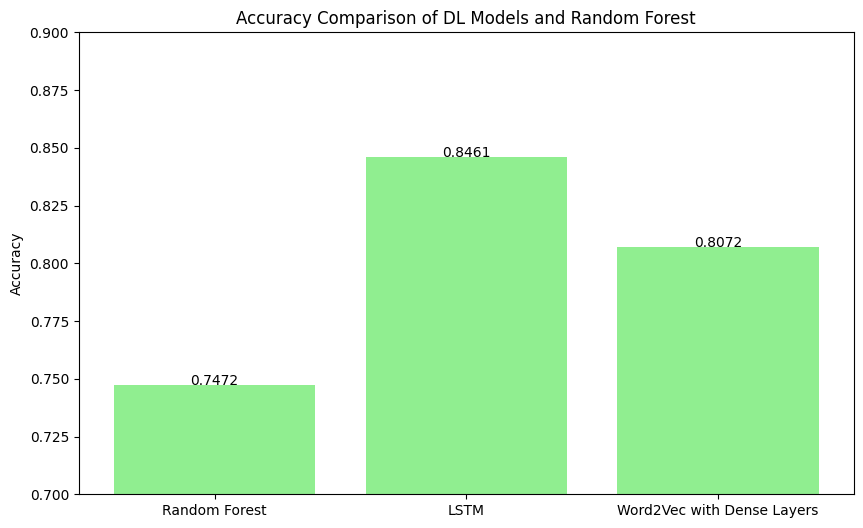

In [ ]:
# Including the Random Forest accuracy to the previous DL models
models = ['Random Forest', 'LSTM', 'Word2Vec with Dense Layers']
accuracies = [0.7472, 0.8461, 0.8072]  # Random Forest accuracy included

# Creating bar plot
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color='lightgreen')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of DL Models and Random Forest')
plt.ylim(0.7, 0.9)  # Setting the limit for y-axis for better visual comparison

# Display the accuracy values on the bars
for i in range(len(models)):
    plt.text(i, accuracies[i], f'{accuracies[i]:.4f}', ha = 'center')

# Show plot
plt.show()
